In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

from scipy.stats import pearsonr
import h5py

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


### Dataset illustration

In [3]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66


filename = '/Users/blancamartin/Downloads/153098.04.02_data.h5' # filename

# open file
f = h5py.File(filename, 'r')


In [4]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times


### Print example pink noise for schematic figure

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_99432/2675696353.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)


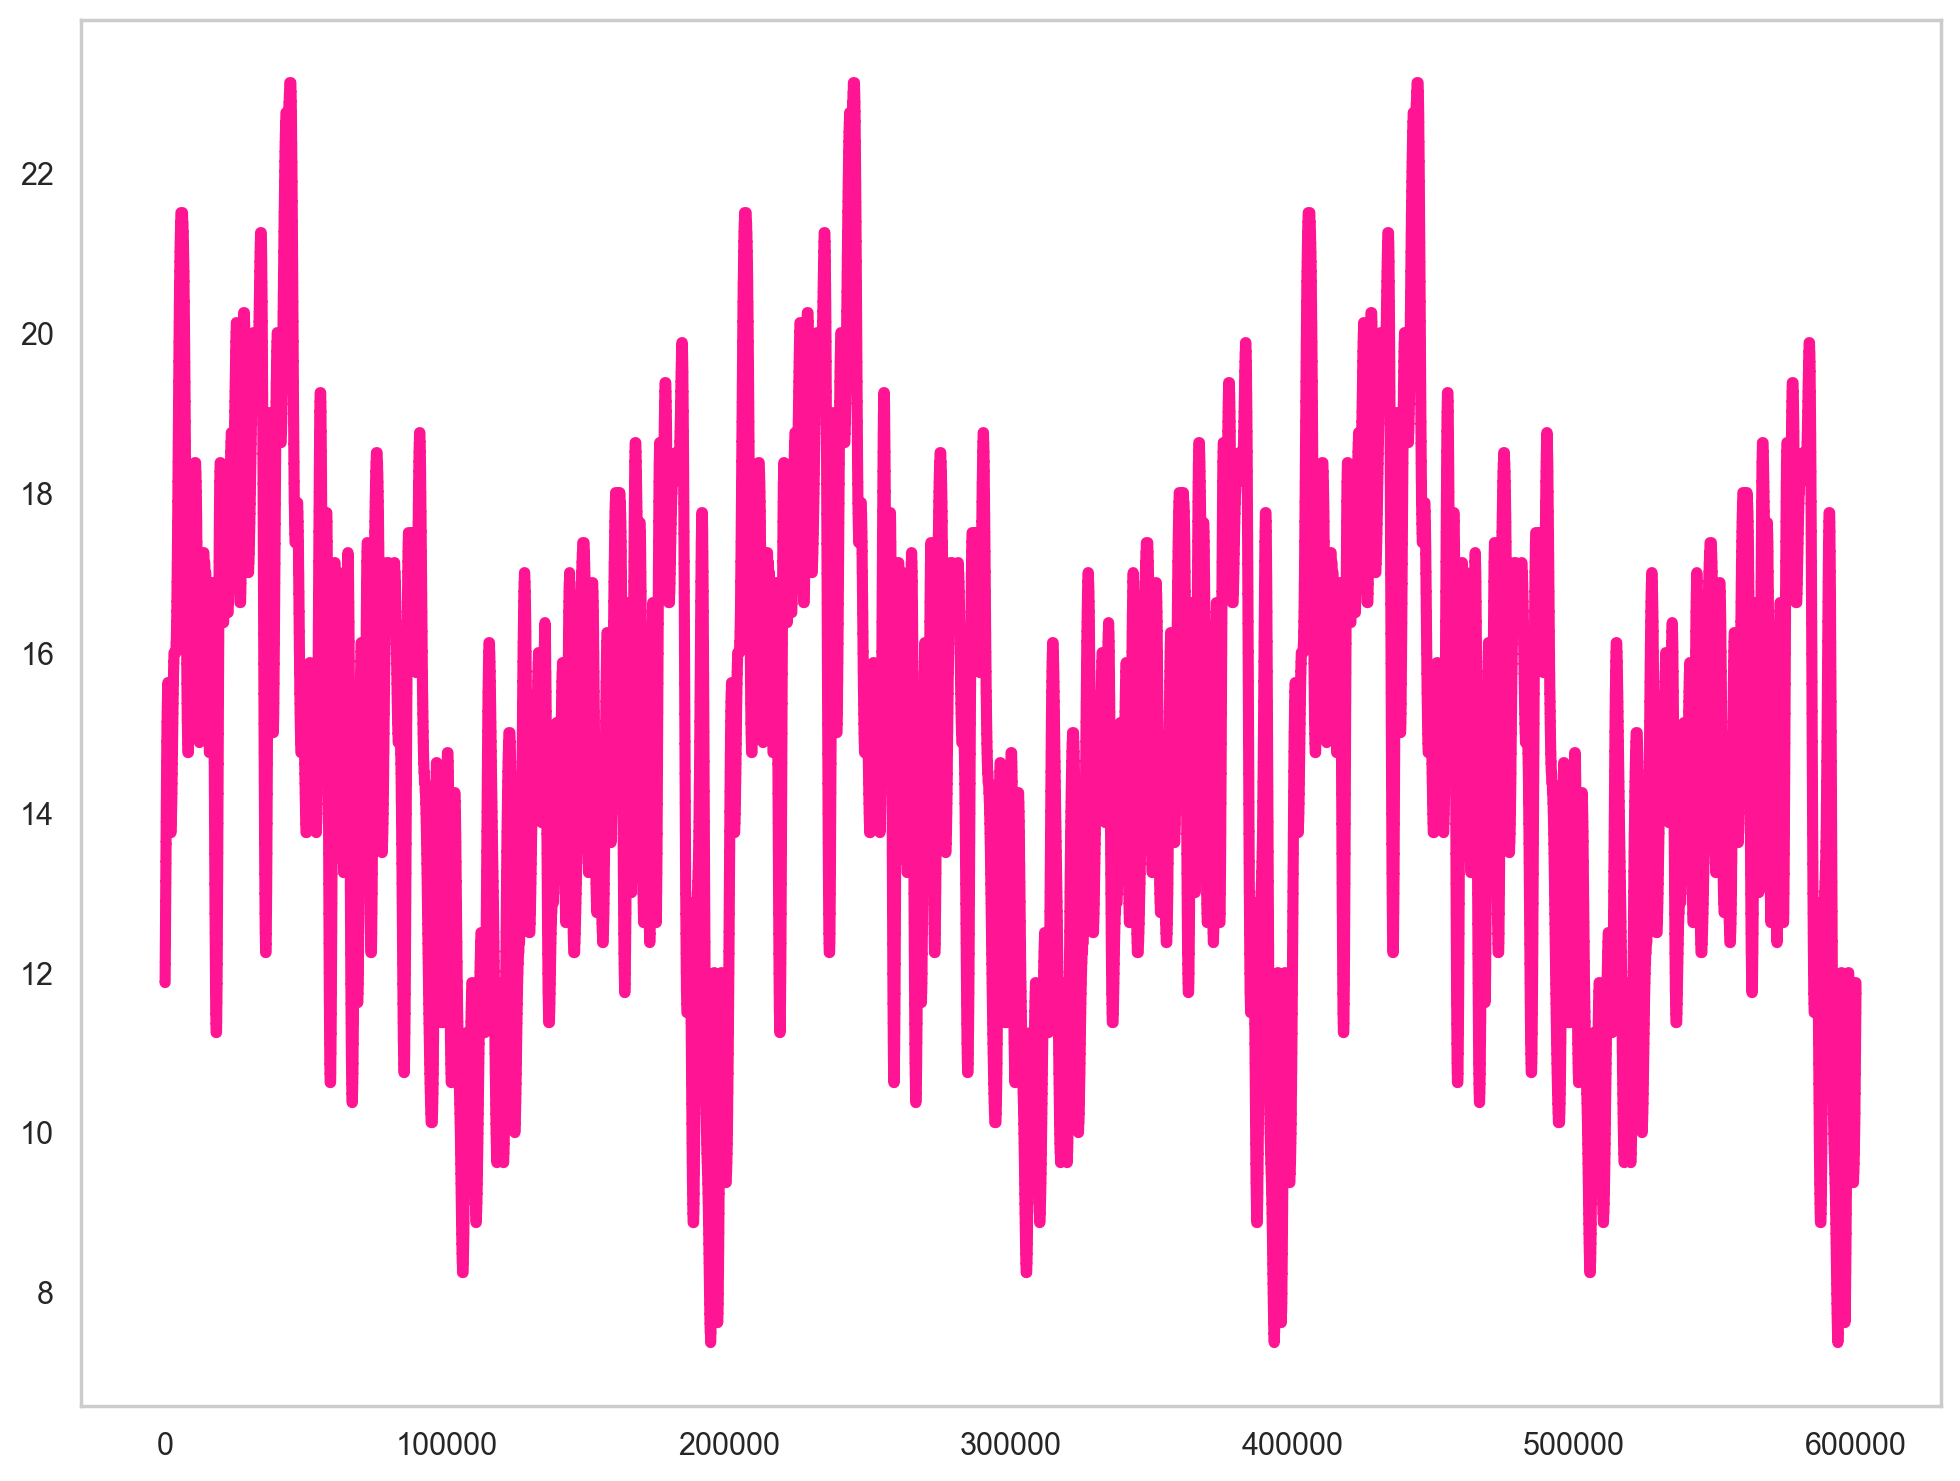

In [5]:

# 0 through 66 sweeps
for i_sweeps in range(66):


    #load data
    dset, times = load_sweep(i_sweeps)

    stim_data = dset[:, 0] # current injection
    

    # set the first 25 ms to zero to get rid of mini-pulse at beginning
    stim_data[0:5000] = 0
    stim_data = stim_data[stim_data!=0]
    
 

    if np.size(stim_data) > 2:
        # a pearson correlation between current and time is
            # nan for constant, near 1.0 for ramp, and low for pink noise
        r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)
        

        # check stim type
        if (np.isnan(r)):
            stim_type = 'constant'
            pink_type = 'constant'
        elif (~np.isnan(r) & (r>0.95)):
            stim_type = 'ramp'
            pink_type = 'ramp'
        elif (~np.isnan(r) & (r<0.95)):
            stim_type = 'pink'
            plt.plot(stim_data, color='deeppink', linewidth = 4)
            break

#### Temporal code figure 

#### Population code figure